In [6]:
import requests
from bs4 import BeautifulSoup

response = requests.get("https://www.weather.go.kr/w/obs-climate/land/city-obs.do")
soup = BeautifulSoup(response.content, 'html.parser')
table = soup.find('table', id='weather_table')

data = []
for tr in table.find_all('tr'):
    tds = list(tr.find_all('td'))

    for td in tds:
        if td.find('a'):
            point = td.find('a').text
            temperature = tds[5].text
            humidity = tds[10].text

            data.append([point, temperature, humidity])



In [7]:
with open('weather.csv', 'w', encoding='utf-8') as file:
    file.write('point,temperature,humidity\n')
    for i in data:
        file.write(f'{i[0]},{i[1]},{i[2]}\n')

In [8]:
# pip install pandas
import pandas as pd

df = pd.read_csv('weather.csv', index_col='point')
df

,temperature,humidity
point,,
강릉,21.1,49
강진군,20.0,61
강화,20.5,45
거제,21.0,59
거창,19.4,57
...,...,...
합천,21.5,52
해남,19.8,59
홍성,19.7,54


In [9]:
city_df = df.loc[['부산', '서울', '인천', '대전', '대구', '울산', '제주']]
city_df

,temperature,humidity
point,,
부산,21.6,51
서울,20.8,43
인천,20.7,43
대전,19.8,55
대구,21.6,47
울산,20.4,49
제주,20.5,72


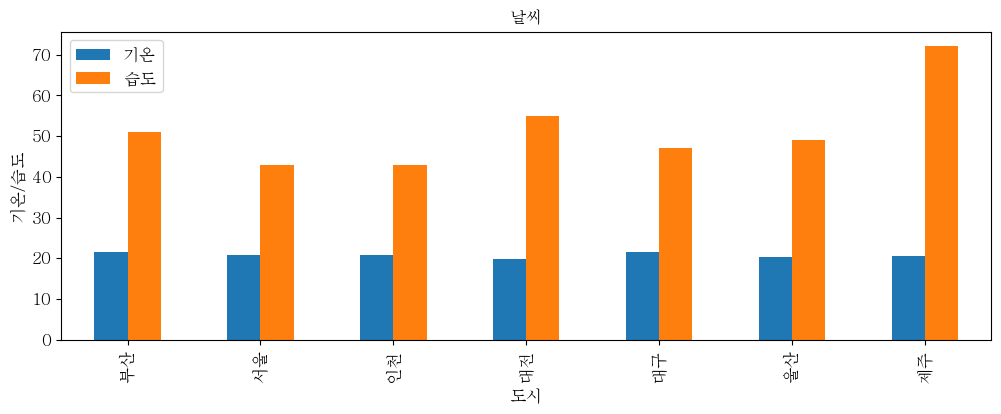

In [10]:
from matplotlib import font_manager, rc
font_path = r'C:\Windows\Fonts\batang.ttc'
font_name = font_manager.FontProperties(fname=font_path).get_name()
rc('font', family=font_name)

ax = city_df.plot(kind='bar', title='날씨', figsize=(12, 4), legend=True, fontsize=12)
ax.set_xlabel('도시', fontsize=12)
ax.set_ylabel('기온/습도', fontsize=12)
ax.legend(['기온', '습도'], fontsize=12)